# `kNNpy.kNN_2D_Ang` Tutorial: Clustering in the sky using 2D $k$-nearest neighbour distributions

# Part 2: Tracer-field cross-clustering

**Author**: Kaustubh Rajesh Gupta (email:[kaustubhrajeshgupta@swin.edu.au](mailto:kaustubhrajeshgupta@swin.edu.au))
\
**Date**: 12 July 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `kNNpy.kNN_2D_Ang` module to compute the 2D tracer-field cross $k$NN distributions in angular coordinates for given data and interpret the results. The basic functionalities of the module are illustrated using realistic cosmological data. A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/kNN_2D_Ang.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

<!--TABLE OF CONTENTS-->
## Contents:

- [Imports and setup](#Imports-and-setup)
- [Load and visualize continuous field: LSST y1 forecast galaxy overdensity field](#mock)
- [Load and vizualize discrete tracers: mock BBHs sampled from the forecast LSST field](#mock_tr)
- [Compute the relevant spatial scales and construct query points](#scale)
- [Define an overdensity threshold for the continous field](#dt)
- [Compute and plot the nearest-neighbour distributions](#cdf)
- [Interpretation of the CDFs](#int)
- [Excess cross-correlation](#psi)
- [Quantifying the clustering signal](#quant)
- [Computational challenge 1](#comp_ch)
- [Thinking challenge 1](#think_ch)
- [Observational masks and nearest-neighbour distributions](#obs)
- [Thinking challenge 2](#think_ch_1)
- [Computational challenge 2](#comp_ch_1)

## Imports and setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues.

In [1]:
#Importing external libraries

import numpy as np

import healpy as hp
from healpy.newvisufunc import projview

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors

import copy

import os
import sys

import warnings

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf                 #some helper functions
from kNNpy import HelperFunctions_2DA as hf_2DA         #2D specifi helper functions
from kNNpy import kNN_2D_Ang                            #the main module
from kNNpy.Data import Datasets                         #helpful for retreiving example datasets

#### We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `ustex==False` if you do not have $\LaTeX$ installed. 

In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 18})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']

## Main

#### <a name="mock" id="mock"></a> In this tutorial, we illustrate how to use `kNNpy` to quantify 2D tracer-field cross-correlations with the $k$-nearest neighbour distributions. For this purpose, we use forecasts for [Rubin Observatory's](https://www.lsst.org/) LSST y1 galaxy overdensity field created using the publicly available [AGORA lightcone simulations](https://yomori.github.io/agora/index.html).

In [4]:
#Setting the NSIDE for the galaxy overdensity field
NSIDE = 512

#Loading the forecast LSST y1 galaxy overdensity field, indicating that we do not want to use the forecast observational footprint
delta_gal_masked = Datasets.Load_forecast_LSSTy1_galaxy_field(masked=False, NSIDE=NSIDE)

#### Let's plot the skymap of the forecast LSST y1 galaxy overdensity field:

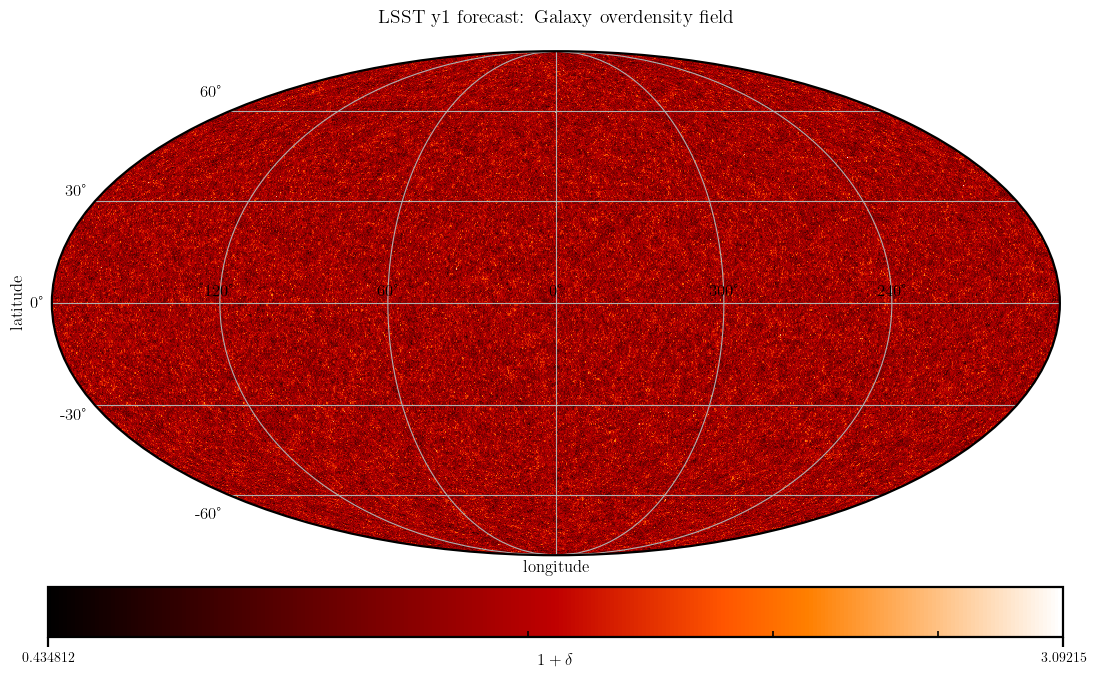

In [5]:
#Plotting the galaxy overdensity map

fig = plt.figure(figsize=(18, 7))
ax1= plt.subplot(1, 1, 1)

plt.axes(ax1)
projview(
    1.+delta_gal_masked,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit=r'$1+\delta$',
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=30,
    projection_type="mollweide",
    title=f"LSST y1 forecast: Galaxy overdensity field\n",
    cmap='gist_heat',
    norm="log", 
    flip="astro",
    min=1+delta_gal_masked[(delta_gal_masked!=hp.UNSEEN)&(delta_gal_masked!=-1)].min(),
    max=1+delta_gal_masked[delta_gal_masked!=hp.UNSEEN].max(),
    hold=True,
    sub=111
)

plt.show()
plt.close()

#### A key research question in cosmology is whether Merging Binary Black Holes (BBHs) are trace fluctuations in the matter overdensity field of the universe. If BBHs preferentially merge inside galaxies, they are expected to be spatially correlated with the galaxy field. 

#### Let's assume the above hypothesis is true, and create 10 realisations of 28,000 mock BBHs by Poisson-sampling the forecast LSST galaxy overdensity field. We will use this data set as the 'discrete tracers', and quantify their cross-correlation with the galaxy density field using the nearest-neightbour distributions.

#### <a name="mock_tr" id="mock_tr"></a> Additionally, let's also create 10 realisations of 28,000 randomly-distributed tracers. This unclustered sample is expected to be uncorrelated with the galaxy overdensity field, and therefore serves as the control data set.

In [6]:
#Number of realisations
n_reals = 10

#Number of tracers in each realisations
n_tracer = 28_000

#Setting a trivial mask to indicate a complete sky coverage
mask = np.ones(12*NSIDE**2)
mask[mask!=1] = hp.UNSEEN

In [7]:
#If you want reproducible results, you can fix the seed used to generate the random sample by providing a value to the seed parameter.

#Creating multiple realisations of merging Binary Black Holes, assuming they are unbiased tracers of the LSST galaxy density field
bbh_pos_masked_ds_arr, bbh_map = Datasets.Sample2DTracersFromField(delta_sampling=delta_gal_masked, mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64)

#Creating the same number of realisations of randoms on the sky to serve as the control.
randoms_pos_masked_ds_arr, randoms_map = Datasets.Sample2DPoissonTracers(mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64)

#### Let's vizualize how the mock BBHs and the randoms are distributed in the sky

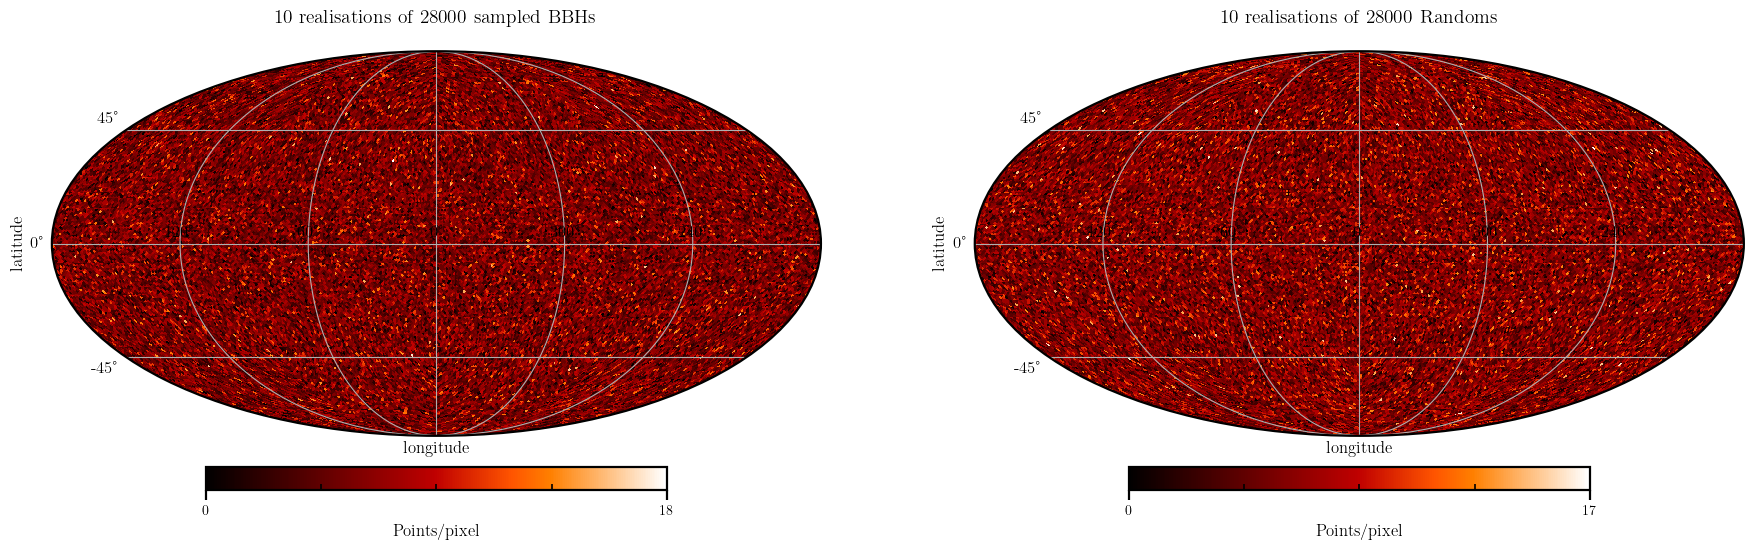

In [8]:
#Plotting the sampled tracers and randoms

fig = plt.figure(figsize=(18, 7))
ax1, ax2 = plt.subplot(1, 2, 1), plt.subplot(1, 2, 2)

plt.axes(ax1)
projview(
    bbh_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_tracer} sampled BBHs\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    # min=map_gal[mask!=hp.UNSEEN].min(),
    # max=map_gal[mask!=hp.UNSEEN].max(),
    hold=True,
    sub=121
)

plt.axes(ax2)
projview(
    randoms_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_tracer} Randoms\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    # min=map_1[mask!=hp.UNSEEN].min(),
    # max=map_1[mask!=hp.UNSEEN].max(),
    hold=True,
    sub=122
)

plt.show()
plt.close()

Note how in this case, it is not obvious from the skymaps whether the tracers are more clustered than the randoms

#### <a name="scale" id="scale"></a> As in the previous tutorials, the first step is to compute the relevant spatial scales of interest at which the $k$NN distributions can be computed. This is dictated by the number density of the sampled tracers, and is computed in a similar way as the previous tutorials:

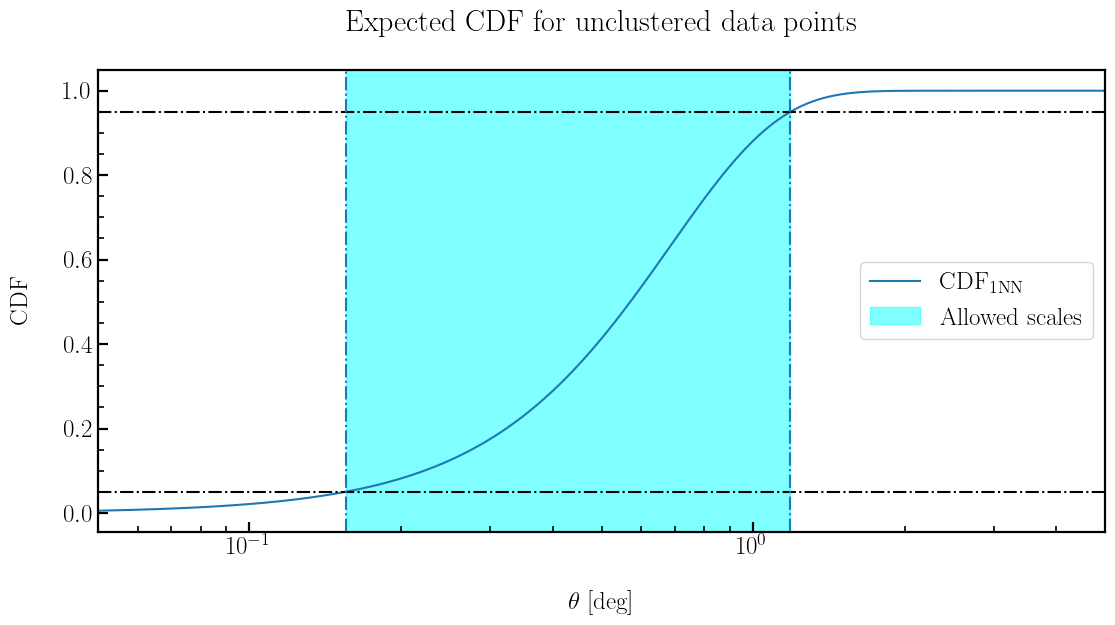

Relevant angular distance scales (deg):

	1NN:	 0.16 1.19
	2NN:	 0.41 1.49
	4NN:	 0.80 1.91


In [9]:
#Defining which neighbours to use
k_List = [1, 2, 4]

#Getting the tracer number density
n_bar_red = (bbh_pos_masked_ds_arr.shape[1]/(4*np.pi))*(12*NSIDE**2/len(np.where(mask!=hp.UNSEEN)[0]))

#Computing the analytical value of the kNN-CDFs for unclustered data on a wide range of angular scales

bins = np.zeros((len(k_List), 10000))
for i, k in enumerate(k_List):
    bins[i] = np.deg2rad(np.geomspace(0.05, 10, 10000))

Theoretical_Uniform_CDFs_test = []
for i, k in enumerate(k_List):
    Theoretical_Uniform_CDFs_test.append(hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(bins[i])), n_bar_red, k))

#Selecting 10 log-spaced bins where the kNN-CDFs are expected to be between 0.05 and 0.95

low_bin = np.zeros(len(k_List)).astype(int)
high_bin = np.zeros(len(k_List)).astype(int)

for i, k in enumerate(k_List):
    low_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.05)
    high_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.95)

sel_bins = np.zeros((len(k_List), 10))
for i, k in enumerate(k_List):
    sel_bins[i] = np.geomspace(bins[i][low_bin[i]]*0.95, bins[i][high_bin[i]]*1.05, 10)

th_uni_arr = np.zeros((len(k_List), sel_bins.shape[1]))
for i, k in enumerate(k_List):
    th_uni_arr[i] = hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(sel_bins[i])), n_bar_red, k)

#Let's plot the expected 1NN-CDF for the unclustered data
plt.figure(figsize=(13,6))
i=0    #change the value of i and k to plot a different kNN-CDF
k=1
plt.plot(np.rad2deg(bins[i]), Theoretical_Uniform_CDFs_test[i], label='CDF$_{{\\rm {}NN}}$'.format(k))
plt.axhline(0.05, ls='-.', c='k')
plt.axhline(0.95, ls='-.', c='k')
plt.axvline(np.rad2deg(bins[i][low_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvline(np.rad2deg(bins[i][high_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvspan(np.rad2deg(bins[i][low_bin[i]]), np.rad2deg(bins[i][high_bin[i]]), alpha=0.5, color=BrightColors[i], label=f'Allowed scales')
plt.xlim([0.05, 5])
plt.title('Expected CDF for unclustered data points\n')
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('CDF\n')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()
plt.close()

#Print out the scales
print('Relevant angular distance scales (deg):\n')
for i, k in enumerate(k_List):
    print(f'\t{k}NN:\t', '{:.2f}'.format(np.rad2deg(bins[i][low_bin[i]])), '{:.2f}'.format(np.rad2deg(bins[i][high_bin[i]])))
# Uncomment lines below to print out the exact scales sampled
# for i, k in enumerate(k_List):
#     print(f'\nAngular distance bins for {k}NN-CDF: \n\n', np.rad2deg(sel_bins[i]))
#     print(f'\nNumber of bins for {k}NN-CDF: ', len(sel_bins[i]))

#### The next step is to construct the query points from which the nearest-neighbour distances are to be computed:

In [10]:
#Generate the query positions
query_mask, query_pos = hf_2DA.create_query_2DA(NSIDE, mask)

#### <a name="dt" id="dt"></a> Finally, we need to set a threshold overdensity (dt) for the continuous field. 

The probability of the field smoothed at a given angular scale exceeding this threshold serves as a measure of the intrinsic clustering of the continuous field, similar to the role played by the $k$NN-CDFs for discrete tracers (see [Banerjee & Abel (2023)](https://academic.oup.com/mnras/article/519/4/4856/6965833) for discussion). 

#### For now, let's set it to the $75^{\rm th}$ percentile of the overdensity map (dt=75), such that the probability of the field exceeding this value is equal to 0.25 at all distance scales. Feel free to play around with this parameter later (note that currently, `kNNpy` only supports a constant percentile density threshold).

In [11]:
delta_threshold = 75.0

#### <a name="cdf" id="cdf"></a> Now, we are ready to measure the tracer-field cross-clustering for our mock datasets. Let's use the `TracerFieldCross2DA()` method to compute the nearest-neighbour distributions for a single realisation of the BBHs and the randoms. 

#### The quantities being computed are:
1. the auto-CDFs for the discrete tracers $\mathcal{P}_{\geq k}$,
2. the continuum limit of the autoCDFs for the continuous field $\mathcal{{P}}_{{>dt}}$, and
3. and the tracer-field cross-CDFs $\mathcal{P}_{\geq k, >dt}$,

#### as defined in 3D by [Banerjee & Abel (2023)](https://academic.oup.com/mnras/article/519/4/4856/6965833) and generalized to 2D angular coordinates by [Gupta & Banerjee (2024)](https://academic.oup.com/mnras/article/531/4/4619/7690170)

In [12]:
#Print the API documentation for details on the function usage
help(kNN_2D_Ang.TracerFieldCross2DA)

Help on function TracerFieldCross2DA in module kNNpy.kNN_2D_Ang:

TracerFieldCross2DA(kList, BinsRad, MaskedQueryPosRad, MaskedTracerPosRad, FieldSkymap, QueryMask, FieldConstPercThreshold, ReturnSmoothedDict=False, Verbose=False)
    Returns the probabilities $P_{\geq k}$, $P_{>{\rm dt}}$ and $P_{\geq k,>{\rm dt}}$ for $k$ in `kList`, that quantify the extent of the spatial cross-correlation between the given discrete tracer positions (`MaskedTracerPosRad`) and the given continuous overdensity field (`FieldSkymap`).

    1. $P_{\geq k}(\theta)$:
        the kNN-CDF of the discrete tracers, evaluated at angular distance scale $\theta$

    2. $P_{>{\rm dt}}(\theta)$:
        the probability of the overdensity field smoothed with a top-hat filter of angular size $\theta$ exceeding the given constant percentile density threshold

    3. $P_{\geq k, >{\rm dt}}(\theta)$:
        the joint probability of finding at least 'k' tracers within a spherical cap of radius $\theta$ AND the overdens

In [13]:
randomxgalaxy_kNN_results = kNN_2D_Ang.TracerFieldCross2DA(k_List, sel_bins, query_pos, randoms_pos_masked_ds_arr[0], delta_gal_masked, query_mask, delta_threshold, ReturnSmoothedDict=False, Verbose=True)

random_autoCDFs = randomxgalaxy_kNN_results[0]    #The auto-CDFs for the randoms
random_pdt = randomxgalaxy_kNN_results[1]         #The intrinsic clustering of the field; is equal to 0.75 at all distance scales for our case 
random_jointCDFs = randomxgalaxy_kNN_results[2]   #The randoms-field cross-CDF

dataxgalaxy_kNN_results = kNN_2D_Ang.TracerFieldCross2DA(k_List, sel_bins, query_pos, bbh_pos_masked_ds_arr[0], delta_gal_masked, query_mask, delta_threshold, ReturnSmoothedDict=False, Verbose=True)

data_autoCDFs = dataxgalaxy_kNN_results[0]        #The auto-CDFs for the BBHs
data_pdt = dataxgalaxy_kNN_results[1]             #The intrinsic clustering of the field; is equal to 0.75 at all distance scales for our case 
data_jointCDFs = dataxgalaxy_kNN_results[2]       #The BBH-field cross-CDF


Checking inputs ...
	done.

initiating step 1 (NN measurements for the discrete tracer set)...

	building the tree ...
		done; time taken: 1.33e-02 s.

	computing the tracer NN distances ...
		done; time taken: 1.33e+01 s.

	computing the tracer auto-CDFs P_{>=k} ...
		done; time taken: 7.01e-01 s.

time taken for step 1: 1.40e+01 s.

initiating step 2 (smoothing the continuous field at the given angular distance scales)...
	done; time taken for step 2: 1.71e+01 s.

initiating step 3 (computing the tracer-field cross-correlation)...

	Computing P_(>dt) and P_(>=k, >dt) for k = 1 ...
	Computing P_(>dt) and P_(>=k, >dt) for k = 2 ...
	Computing P_(>dt) and P_(>=k, >dt) for k = 4 ...

	done; time taken for step 3: 5.87e-01 s.

total time taken: 3.17e+01 s.
Checking inputs ...
	done.

initiating step 1 (NN measurements for the discrete tracer set)...

	building the tree ...
		done; time taken: 5.16e-03 s.

	computing the tracer NN distances ...
		done; time taken: 1.38e+01 s.

	computing t

#### let's plot the results

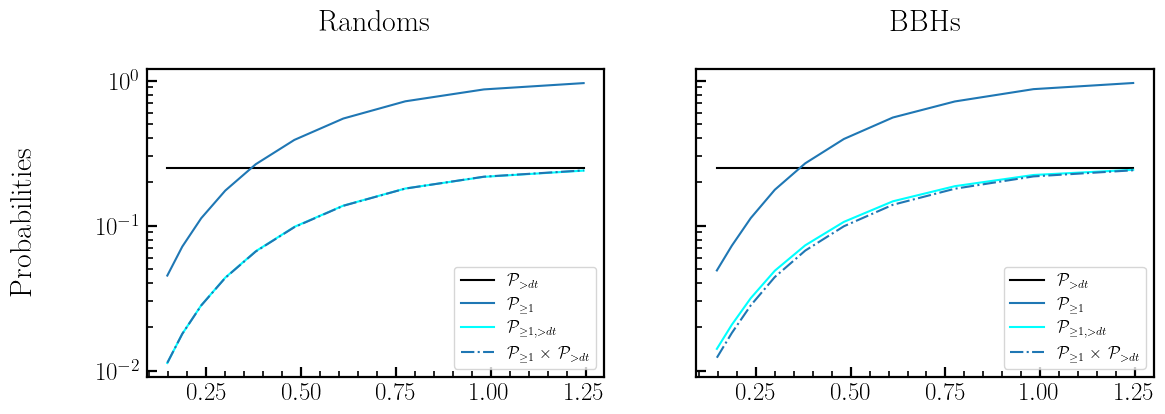

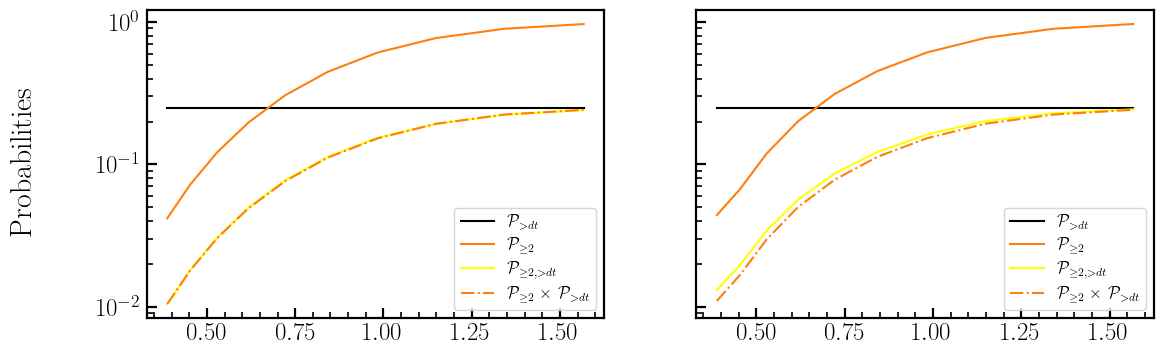

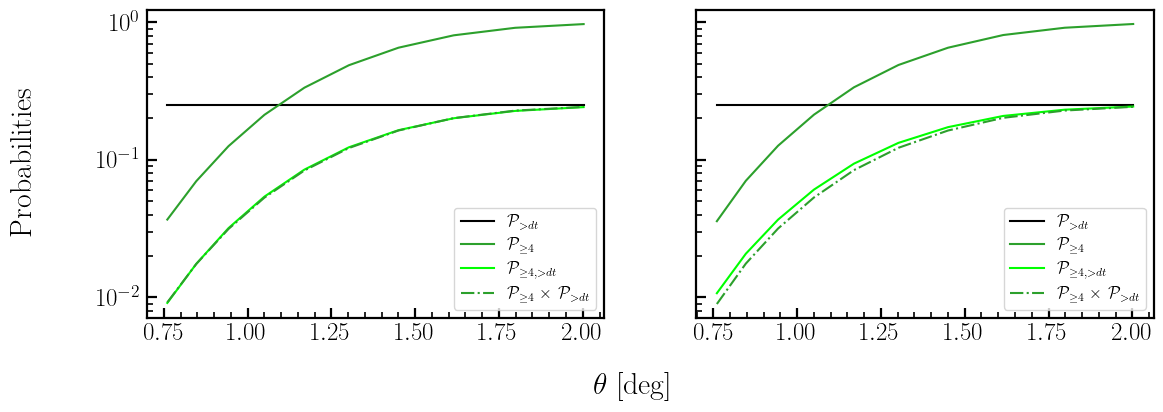

In [14]:
for i, k in enumerate(k_List):

    fig, (ax, ax1) = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)
    
    ax.plot(np.rad2deg(sel_bins[i]), random_pdt[i], c='k', label='$\\mathcal{{P}}_{{>dt}}$')
    ax.plot(np.rad2deg(sel_bins[i]), random_autoCDFs[i], c=DefaultColorCycle[i], label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$'.format(k))
    ax.plot(np.rad2deg(sel_bins[i]), random_jointCDFs[i], c=BrightColors[i], label='$\\mathcal{{P}}_{{\\geq {:.0f}, >dt}}$'.format(k))
    ax.plot(np.rad2deg(sel_bins[i]), random_autoCDFs[i]*random_pdt[i], c=DefaultColorCycle[i], ls='-.', label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$'.format(k))
    ax.legend(fontsize=12)
    if i==0: ax.set_title('Randoms\n')
    
    ax1.plot(np.rad2deg(sel_bins[i]), data_pdt[i], c='k', label='$\\mathcal{{P}}_{{>dt}}$')
    ax1.plot(np.rad2deg(sel_bins[i]), data_autoCDFs[i], c=DefaultColorCycle[i], label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$'.format(k))
    ax1.plot(np.rad2deg(sel_bins[i]), data_jointCDFs[i], c=BrightColors[i], label='$\\mathcal{{P}}_{{\\geq {:.0f}, >dt}}$'.format(k))
    ax1.plot(np.rad2deg(sel_bins[i]), data_autoCDFs[i]*data_pdt[i], c=DefaultColorCycle[i], ls='-.', label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$'.format(k))
    ax1.legend(fontsize=12)
    if i==0: ax1.set_title('BBHs\n')

    if i==len(k_List)-1: fig.supxlabel(r'$\theta$ [deg]', y=-0.1)
    fig.supylabel('Probabilities')

    plt.yscale('log')
    plt.show()
    plt.close()

#### <a name="int" id="int"></a> Interpretation

let's focus on the $k=1$ panels (top row). The first thing to note is that $\mathcal{P}_{>dt}$ (solid black line) is constant at all angular scales and is equal to 0.25. This is by design, since we chose a constant-percentile density threshold of 0.75. Second, $\mathcal{P}_{\geq 1}$ (the solid blue line) simply represents the 1NN auto-CDF of for the discrete tracers, and goes from close to 0 to close to 1, as we have seen in earlier tutorials. 

Third, $\mathcal{P}_{\geq 2, >dt}$ (the solid cyan line) represents the spatial cross-correlation between the discrete tracers and the continuous field. At each angular scale $\theta$, its value is equal to the joint probability of finding at least 1 discrete tracer around a randomly-chosen sky region of angular radius $\theta$ and the continuous field smoothed over angular scale $\theta$ exceeding the density threshold $dt$. Note that $\mathcal{P}_{\geq 2, >dt}$ saturates to $\mathcal{P}_{>dt}$ at large angular scales, since the probability of finding at least 1 tracer at those angular scales is near unity. 

Fourth, the absolute value of $\mathcal{P}_{\geq 2, >dt}$ on its own is not enough to judge whether the tracers and field are correlated or not, because there is a non-zero probability of spatial overlap even if they are uncorrelated. For this purpose, we need to examine the product $\mathcal{P}_{\geq 2, >dt} \times \mathcal{P}_{>dt}$ (dashed blue line). This is because if the tracer and field are uncorrelated, meaning their spatial distrubutions are indepenent of each other, the joint probability $\mathcal{P}_{\geq 2, >dt}$ is equal to the product of the individual probabilites $\mathcal{P}_{\geq 2, >dt}$ and $\mathcal{P}_{>dt}$. On the other hand, if the tracers are spatially correlated (anti-correlated) with the field, they are more (less) likely to be located in overdense sky regions than underdense ones, meaning that the joint probability should be greater (lesser) than the product of the individual probabilites. Hence, this product serves as a reference curve to be compared against $\mathcal{P}_{\geq 2, >dt}$.

We see in the top row of the figure above, that $\mathcal{P}_{\geq 2, >dt}$ is almost identically equal to $\mathcal{P}_{\geq 2, >dt} \times \mathcal{P}_{>dt}$ in case of the randoms (left panel), while it is larger than $\mathcal{P}_{\geq 2, >dt} \times \mathcal{P}_{>dt}$ in case of the mock BBHs (right panel). Therefore, we can say that the randoms are uncorrelated with the simulated LSST galaxy overdensity field, while the mock BBHs are positively correlated with it.

This argument generalizes to all nearest neighbours, and can be seen in the remaining rows of the figure.

#### <a name="psi" id="psi"></a> To make it easier to vizualize the clustering signal, we can compute a quantity known as the excess cross-correlation, which is defined as [(Banerjee & Abel 2023)](https://academic.oup.com/mnras/article/519/4/4856/6965833)
$\psi_{k, dt} = \frac{\mathcal{P}_{\geq k, >dt}}{\mathcal{P}_{\geq k}\times\mathcal{{P}}_{{>dt}}}$

#### An excess cross-correlation of greater (lesser) than 1 implies that the tracers are positively (negatively) correlated with the field, while a unity value indicates that the tracers are uncorrelated with the field. Let's compute this quantity using the in-built helper function `kNN_excess_cross_corr()` and plot it as a function of angular scale.

In [15]:
randoms_psi = hf.kNN_excess_cross_corr(random_autoCDFs, random_pdt, random_jointCDFs)
data_psi = hf.kNN_excess_cross_corr(data_autoCDFs, data_pdt, data_jointCDFs)

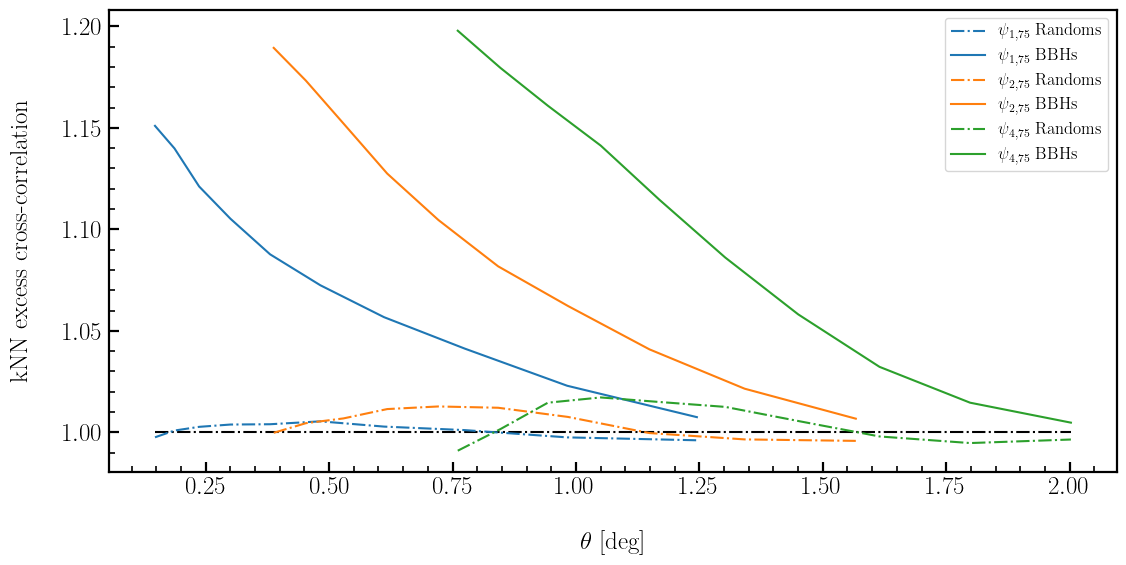

In [30]:
plt.figure(figsize=(13, 6))

x_plots = np.linspace(sel_bins[0][0], sel_bins[-1][-1], 100)
plt.plot(np.rad2deg(x_plots), np.ones_like(x_plots), 'k-.', label=None)

for i, k in enumerate(k_List):
    plt.plot(np.rad2deg(sel_bins[i]), randoms_psi[i], c=DefaultColorCycle[i], ls='-.', label='$\\psi_{{{:.0f}, {:.0f}}}$ Randoms'.format(k, delta_threshold))
    plt.plot(np.rad2deg(sel_bins[i]), data_psi[i], c=DefaultColorCycle[i], label='$\\psi_{{{:.0f}, {:.0f}}}$ BBHs'.format(k, delta_threshold))
        
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('kNN excess cross-correlation\n')
plt.legend(fontsize=12)
plt.show()
plt.close()

#### We see that the mock BBHs indeed appear correlated with the field, as expected, while the randoms appear uncorrelated.

#### <a name="quant" id="quant"></a> Quantifying the clustering signal

As in the earlier tutorial on the 2D auto-CDFs, we need to quantify the noise in our measurements to be certain that we are detecting a cross-correlation signal, and to quantify the extent of the clustering. Let's cross-correlate the set of Poisson-distributed 'randoms' realisations we created earlier with the LSST overdensity field, and measure the variance in the nearest-neighbour distributions across the realisations. Let's also perform the measurements on the other independent realisations of the mock BBHs we created earlier, to get an additional estimate of the variance in the signal. Remember, we are only able to do this since this is a simulated data set; in actual observations, we only have access to a single realisation of data.

To measure the cross-correlation for multiple realisations, we make use of the in-built `kNN_2D_Ang.TracerFieldCross2DA_DataVector()` method.

**Caution:** since we are running 20 realisations, this calculation will take some time to complete (approximately 5-10 minutes). If you want quicker results, reduce the number of realisations by chaning the ``n_reals`` parameter, although that will reduce the quality of the results.

In [17]:
#Print the API documentation for details on the function usage
help(kNN_2D_Ang.TracerFieldCross2DA_DataVector)

Help on function TracerFieldCross2DA_DataVector in module kNNpy.kNN_2D_Ang:

TracerFieldCross2DA_DataVector(kList, BinsRad, MaskedQueryPosRad, MaskedTracerPosVectorRad, FieldSkymap, QueryMask, FieldConstPercThreshold, ReturnSmoothedDict=False, Verbose=False)
    Returns 'data vectors' of the  the probabilities $P_{\geq k}$, $P_{>{\rm dt}}$ and $P_{\geq k,>{\rm dt}}$ [refer to kNNpy.kNN_2D_Ang.TracerFieldCross2DA for definitions] for $k$ in `kList` for multiple realisations of the given discrete tracer set [`MaskedTracerPosVectorRad`] and a single realisation of the given continuous overdensity field (`FieldSkymap`). Please refer to notes to understand why this might be useful.

    Parameters
    ----------
    kList : int
        the list of nearest neighbours to calculate the distances to. For example, if ``kList = [1, 2, 4]``, the first, second and fourth-nearest neighbour distributions will be computed.
    BinsRad : list of numpy float array
        list of angular distance arrays

In [20]:
# Let's create a combined list of the independent realisations of the randoms and the mock BBHs. This is just so we can get the results using a single call to the function, but you can compute the results separately if you want.

combined_pos_masked_ds_arr = np.concatenate([randoms_pos_masked_ds_arr, bbh_pos_masked_ds_arr], axis=0)

In [21]:
#Computing the nearest-neighbour distributions

bbhxgalaxy_kNN_results_DataVector = kNN_2D_Ang.TracerFieldCross2DA_DataVector(k_List, sel_bins, query_pos, combined_pos_masked_ds_arr, delta_gal_masked, query_mask, delta_threshold, ReturnSmoothedDict=False, Verbose=True)

Checking inputs ...
	done.

initiating step 1 (smoothing the continuous field at the given angular distance scales)...
	done; time taken for step 1: 1.66e+01 s.

initiating step 2 (looping the tracer-field cross-correlation computations over the multiple tracer realisations)...


--------------  Realisation 1/20  --------------


building the BallTree for the discrete tracer set ...
	done; time taken: 5.41e-03 s.

computing the tracer NN distances ...
	done; time taken: 1.38e+01 s.

computing the tracer auto-CDFs P_{>=k} ...
	done; time taken: 7.23e-01 s.

computing the tracer-field cross-correlation ...

	Computing P_(>dt) and P_(>=k, >dt) for k = 1 ...
	Computing P_(>dt) and P_(>=k, >dt) for k = 2 ...
	Computing P_(>dt) and P_(>=k, >dt) for k = 4 ...

	done; time taken: 5.72e-01 s.

time taken for realisation 1: 1.51e+01 s.


--------------  Realisation 2/20  --------------


building the BallTree for the discrete tracer set ...
	done; time taken: 5.75e-03 s.

computing the tracer NN

In [24]:
#Let's extract the auto and cross components of the nearest-neighbour measurements, and compute the excess cross-correlation

autoCDFs = bbhxgalaxy_kNN_results_DataVector[0]
pdt = bbhxgalaxy_kNN_results_DataVector[1]
jointCDFs = bbhxgalaxy_kNN_results_DataVector[2]
psi = hf.kNN_excess_cross_corr(autoCDFs, pdt, jointCDFs)

#### Let's plot up the mean of the excess cross-correlations for the mock BBHs and the randoms, with the individual realisations in the background to illustrate the uncertainties

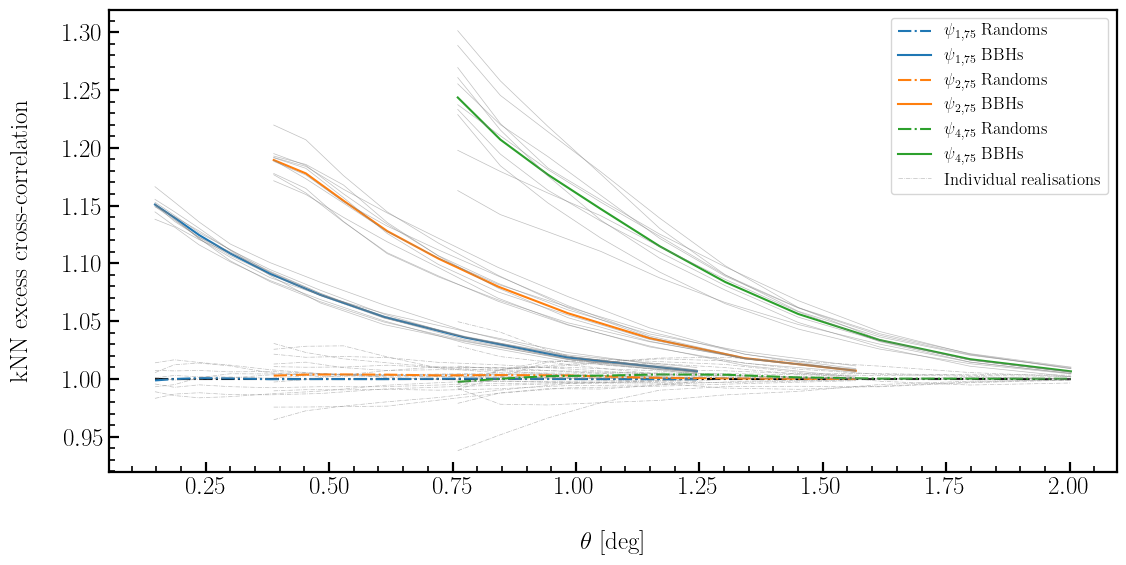

In [32]:
plt.figure(figsize=(13, 6))

x_plots = np.linspace(sel_bins[0][0], sel_bins[-1][-1], 100)
plt.plot(np.rad2deg(x_plots), np.ones_like(x_plots), 'k-.', label=None)

for i, k in enumerate(k_List):
    
    plt.plot(np.rad2deg(sel_bins[i]), np.mean(psi[i][:n_reals], axis=0), c=DefaultColorCycle[i], ls='-.', label='$\\psi_{{{:.0f}, {:.0f}}}$ Randoms'.format(k, delta_threshold))
    for realisation in range(1, n_reals):
        plt.plot(np.rad2deg(sel_bins[i]), psi[i][:n_reals][realisation], c='grey', ls='-.', lw=0.5, alpha=0.5, label=None)

    plt.plot(np.rad2deg(sel_bins[i]), np.mean(psi[i][n_reals:], axis=0), c=DefaultColorCycle[i], label='$\\psi_{{{:.0f}, {:.0f}}}$ BBHs'.format(k, delta_threshold))
    for realisation in range(n_reals):
        plt.plot(np.rad2deg(sel_bins[i]), psi[i][n_reals:][realisation], c='grey', lw=0.5, alpha=0.5, label=None)

plt.plot(np.rad2deg(sel_bins[i]), psi[i][:n_reals][0], c='grey', ls='-.', lw=0.5, alpha=0.5, label='Individual realisations')
        
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('kNN excess cross-correlation\n')
plt.legend(fontsize=12)
plt.show()
plt.close()

#### We can clearly see a strong separation between the BBHs and the randoms, even taking into account the spread across the realisations, demonstrating the detection of a robust clustering signal. Further note how the average across the randoms is very close to 1, as expected for a sample that is uncorrelated with the continuous field. This serves as a sanity check for our analysis.

#### <a name="comp_ch" id="comp_ch"></a> Computational challenge

Just as you did for the auto-correlations in part 1, try to compute the statistical significance of the cross-correlation detection. 

**Bonus challenge 1:** Try to increase and decrease the number of tracers in each realisation by changing the ``n_tracer`` parameter. Does this change the statistical significance of the detection? How can you explain this change?

**Bonus challenge 2**: Now try to vary the number of realisations used in the analysis, keeping the number of tracers fixed. Does this change the statistical significance of the detection? Should it?

In [34]:
#Type your solution below

#### <a name="think_ch" id="think_ch"></a> Thinking challenge

We used the normalised excess-cross correlation $\psi$ across the independent BBH and randoms realisations to quantify the cross-correlation signal. Can we directly use the tracer-field cross-CDF instead for the same purpose? What is the purpose of the normalised excess-cross correlation?

#### <a name="obs" id="obs"></a> Observational masks and nearest-neighbour calculations

So far, we have worked with simulated datasets that cover the entire sky. However, in practice, it is rare for observational data sets to have an all-sky coverage. Generally, astronomical surveys such as SDSS, LSST, etc. provide data only on limited parts of the sky, due to a multitude of reasons, such as the geographic location of telescopes, presence of sky regions with exceptionally high stellar densities, and obscuration due to the plane of the milky way, among others (with gravitational wave surveys being a notable exception). As a result, most data sets contain 'bad regions' of the sky outside the 'observational footprint' that need to be masked out before analysis. For example, here is how the forecast observational footprint for LSST looks like, with the blue (yellow) regions representing the good (bad) sky locations:

In [35]:
#Loading the forecast LSST y1 galaxy overdensity field and the forecast observational footprint
delta_gal_masked, mask = Datasets.Load_forecast_LSSTy1_galaxy_field(masked=True, NSIDE=NSIDE)

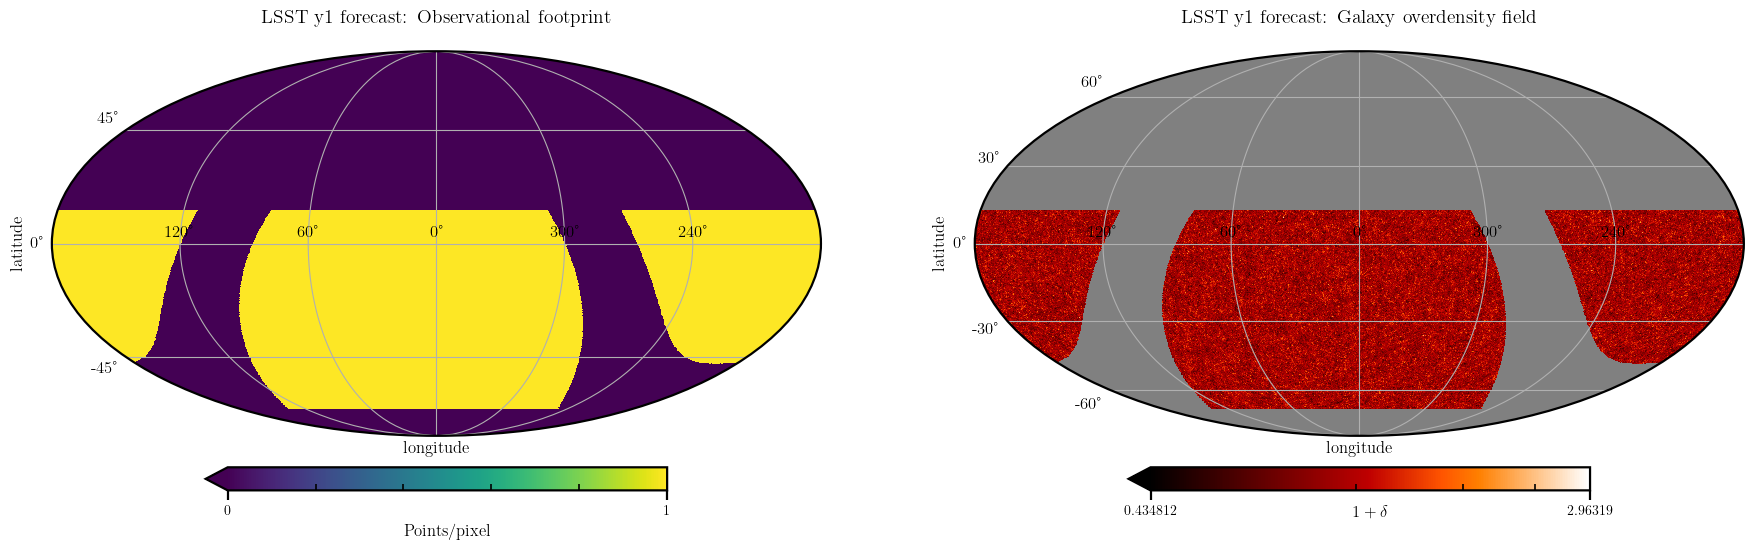

In [45]:
#Plotting the galaxy overdensity map

fig = plt.figure(figsize=(18, 7))
ax1, ax2 = plt.subplot(1, 2, 1), plt.subplot(1, 2, 2)

plt.axes(ax1)
projview(
    mask,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"LSST y1 forecast: Observational footprint\n",
    norm="linear", 
    flip="astro",
    min=0,
    max=1,
    hold=True,
    sub=121
)http://localhost:8888/lab/tree/Tutorials/kNN_2D_Ang_tutorial_2_tracer_field_cross_clustering.ipynb#obs

plt.axes(ax2)
projview(
    1.+delta_gal_masked,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit=r'$1+\delta$',
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=30,
    projection_type="mollweide",
    title=f"LSST y1 forecast: Galaxy overdensity field\n",
    norm="log", 
    flip="astro",
    cmap='gist_heat',
    min=1+delta_gal_masked[(delta_gal_masked!=hp.UNSEEN)&(delta_gal_masked!=-1)].min(),
    max=1+delta_gal_masked[delta_gal_masked!=hp.UNSEEN].max(),
    hold=True,
    sub=122
)

plt.show()
plt.close()

#### In presence of masked data, we need to be very careful while computing the nearest neighbour distributions to avoid introducing boundary effect-related biases in the clustering measurements.

For example, if we simply compute the clustering of the masked data (right panel above) in the usual manner, we will see an artificially high clustering signal due to the massive 'voids' created by the missing data in the bad sky regions!

To account for the effects due to masks, we need to take the following steps:

1. In case the sky coverage of the discrete tracers is larger than that of the continuous field, we must discard the tracers located outside the observational footprint of the field. This is particularly relevant if our tracers are observed using a different survey or observational technique than the field (example: BBHs observed with gravitational wave detectors, which have all-sky coverage).
2. Similarly, we must discard all the randoms outside the field's observational footprint.
3. In case we have data for the continuous field in regions with no data for the tracers, we need to mask out the continuous field in those regions and create a new observational footprint. This is not relevant for our present example.

These steps are necessary, since we cannot compute tracer-field cross-correlations in spatial regions with no data for the field. Let us re-create 10 realisations of mock BBHs and randoms with the same number density in the sky as before, but restricted to within the LSST footprint. Note that the LSST y1 data will cover about 43% of the sky, so our total number of objects will go down from 28,000 to approximately 12,000.

In [47]:
#Number of tracers in each realisations, maintaining same number density as before
n_tracer = int(28_000*len(np.where(mask!=hp.UNSEEN)[0])/len(mask))
print(n_tracer)

12121


In [48]:
#Creating multiple realisations of merging Binary Black Holes, assuming they are unbiased tracers of the LSST galaxy density field
delta_gal = Datasets.Load_forecast_LSSTy1_galaxy_field(masked=False, NSIDE=NSIDE)    #remember, for sampling, we need unmasked galaxy density field
bbh_pos_masked_ds_arr, bbh_map = Datasets.Sample2DTracersFromField(delta_sampling=delta_gal, mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64)

#Creating the same number of realisations of randoms on the sky to serve as the control
randoms_pos_masked_ds_arr, randoms_map = Datasets.Sample2DPoissonTracers(mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64)

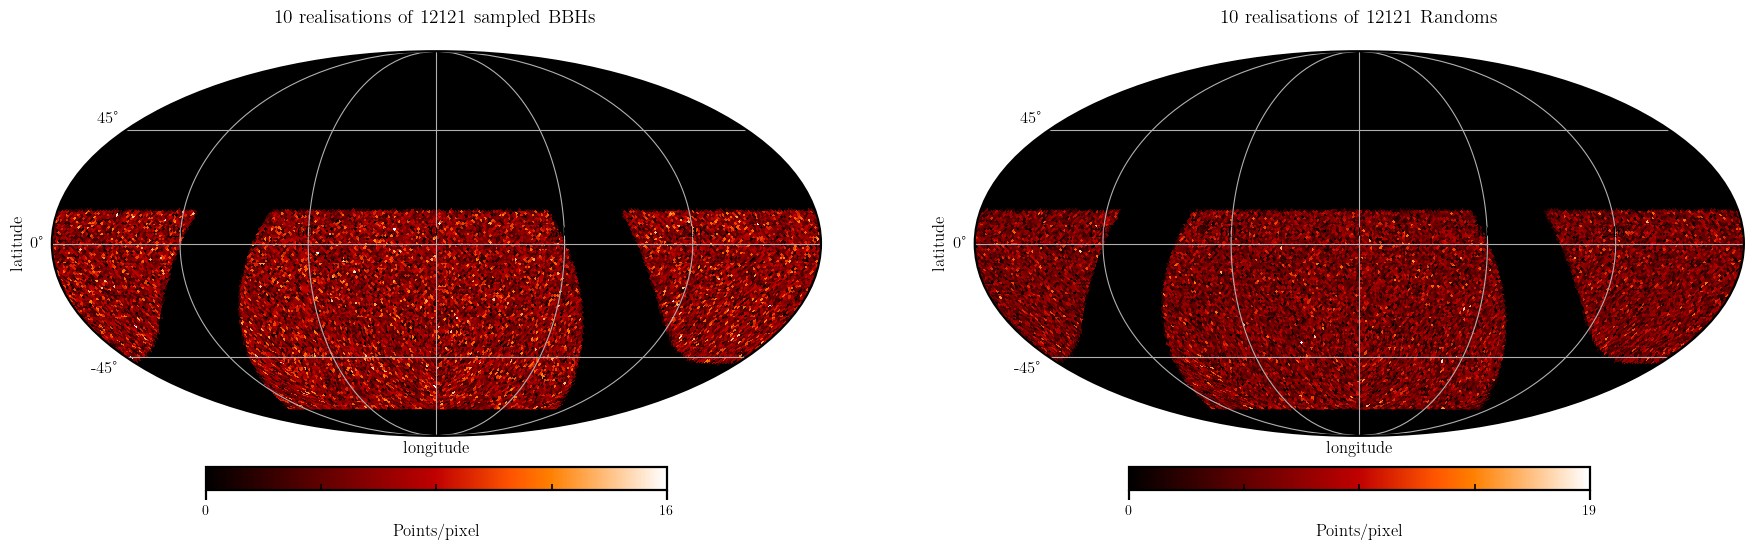

In [52]:
#Plotting the sampled tracers and randoms

fig = plt.figure(figsize=(18, 7))
ax1, ax2 = plt.subplot(1, 2, 1), plt.subplot(1, 2, 2)

plt.axes(ax1)
projview(
    bbh_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_tracer} sampled BBHs\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    hold=True,
    sub=121
)

plt.axes(ax2)
projview(
    randoms_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_tracer} Randoms\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    hold=True,
    sub=122
)

plt.show()
plt.close()

#### Since we maintained the same number density as before, the spatial scales of interest will be the same, but let us confirm this by running the code below:

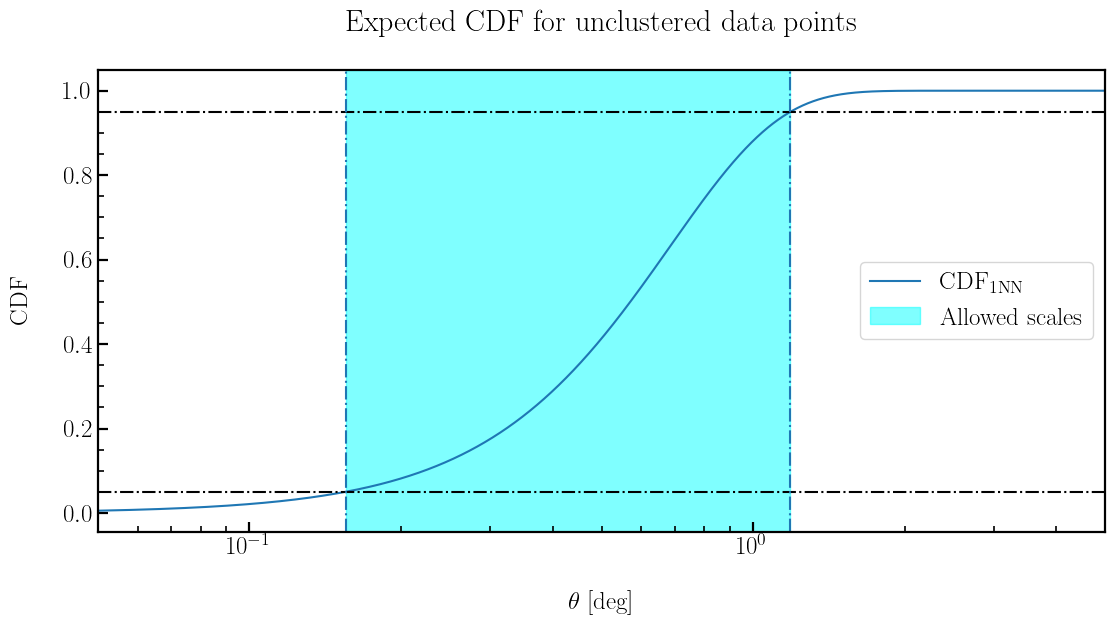

Relevant angular distance scales (deg):

	1NN:	 0.16 1.19
	2NN:	 0.41 1.49
	4NN:	 0.80 1.91


In [53]:
#Defining which neighbours to use
k_List = [1, 2, 4]

#Getting the tracer number density
n_bar_red = (bbh_pos_masked_ds_arr.shape[1]/(4*np.pi))*(12*NSIDE**2/len(np.where(mask!=hp.UNSEEN)[0]))

#Computing the analytical value of the kNN-CDFs for unclustered data on a wide range of angular scales

bins = np.zeros((len(k_List), 10000))
for i, k in enumerate(k_List):
    bins[i] = np.deg2rad(np.geomspace(0.05, 10, 10000))

Theoretical_Uniform_CDFs_test = []
for i, k in enumerate(k_List):
    Theoretical_Uniform_CDFs_test.append(hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(bins[i])), n_bar_red, k))

#Selecting 10 log-spaced bins where the kNN-CDFs are expected to be between 0.05 and 0.95

low_bin = np.zeros(len(k_List)).astype(int)
high_bin = np.zeros(len(k_List)).astype(int)

for i, k in enumerate(k_List):
    low_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.05)
    high_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.95)

sel_bins = np.zeros((len(k_List), 10))
for i, k in enumerate(k_List):
    sel_bins[i] = np.geomspace(bins[i][low_bin[i]]*0.95, bins[i][high_bin[i]]*1.05, 10)

th_uni_arr = np.zeros((len(k_List), sel_bins.shape[1]))
for i, k in enumerate(k_List):
    th_uni_arr[i] = hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(sel_bins[i])), n_bar_red, k)

#Let's plot the expected 1NN-CDF for the unclustered data
plt.figure(figsize=(13,6))
i=0    #change the value of i and k to plot a different kNN-CDF
k=1
plt.plot(np.rad2deg(bins[i]), Theoretical_Uniform_CDFs_test[i], label='CDF$_{{\\rm {}NN}}$'.format(k))
plt.axhline(0.05, ls='-.', c='k')
plt.axhline(0.95, ls='-.', c='k')
plt.axvline(np.rad2deg(bins[i][low_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvline(np.rad2deg(bins[i][high_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvspan(np.rad2deg(bins[i][low_bin[i]]), np.rad2deg(bins[i][high_bin[i]]), alpha=0.5, color=BrightColors[i], label=f'Allowed scales')
plt.xlim([0.05, 5])
plt.title('Expected CDF for unclustered data points\n')
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('CDF\n')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()
plt.close()

#Print out the scales
print('Relevant angular distance scales (deg):\n')
for i, k in enumerate(k_List):
    print(f'\t{k}NN:\t', '{:.2f}'.format(np.rad2deg(bins[i][low_bin[i]])), '{:.2f}'.format(np.rad2deg(bins[i][high_bin[i]])))
# Uncomment lines below to print out the exact scales sampled
# for i, k in enumerate(k_List):
#     print(f'\nAngular distance bins for {k}NN-CDF: \n\n', np.rad2deg(sel_bins[i]))
#     print(f'\nNumber of bins for {k}NN-CDF: ', len(sel_bins[i]))

#### Modification to query points

A final key modification is needed before we can compute the nearest neighbour distributions, to avoid biases due boundary effects: we need to re-create the query points used to compute nearest-neighbour distances!

1. We need to remove all query points outside the observational footprint. This should make sense, as the nearest neighbour of a query point outside the footprint would be artificially large. Given this affects a large fraction of query points, it will bias the nearest-neighbour distributions
2. We need to remove query points that are with a certain threshold angular distance of the boundary of the observational footprint (ie., we need to 'pad' the query points). This threshold scale, known as the 'tolerance', is typically set at approximately half of the largest angular scale probed by the first-nearest neighbour distribution.

#### Let's illustrate query point padding using an exaggerated tolerance of 10 deg to make it clearly visible.
**Warning:** it can take about 3-5 minutes to generate padded query points for a `HEALPix` grid of ``NSIDE=512`` and tolerance 10 deg.

In [54]:
query_mask_demo, query_pos_demo = hf_2DA.create_query_2DA(NSIDE, mask, tolerance=np.deg2rad(10))

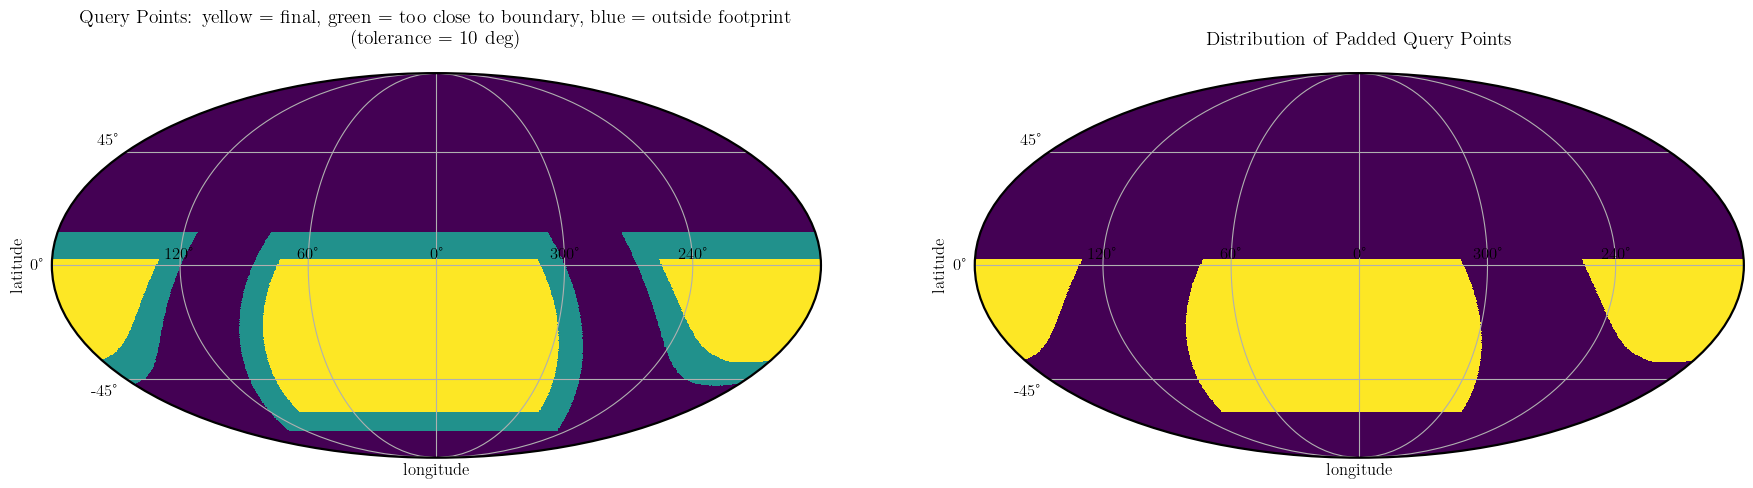

In [59]:
fig = plt.figure(figsize=(18, 7))
ax1, ax2 = plt.subplot(1, 2, 1), plt.subplot(1, 2, 2)

plt.axes(ax1)
projview(
    query_mask_demo,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=False,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"Query Points: yellow = final, green = too close to boundary, blue = outside footprint \n(tolerance = {10} deg)\n",
    norm="linear", 
    flip="astro",
    min = 0,
    max = 2,
    hold=True,
    sub=121
)

hpx_querymap = hf_2DA.cat2hpx(np.rad2deg(query_pos_demo)[:, 1], np.rad2deg(query_pos_demo)[:, 0], nside=NSIDE, radec=False)
plt.axes(ax2)
projview(
    hpx_querymap,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=False,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title="Distribution of Padded Query Points\n",
    norm="linear", 
    flip="astro",
    hold=True,
    sub=122
)

plt.show()
plt.close()

#### Let's recompute the query points, giving a more realistic tolerance of 0.5 deg

In [60]:
query_mask, query_pos = hf_2DA.create_query_2DA(NSIDE, mask, tolerance=np.deg2rad(0.5))

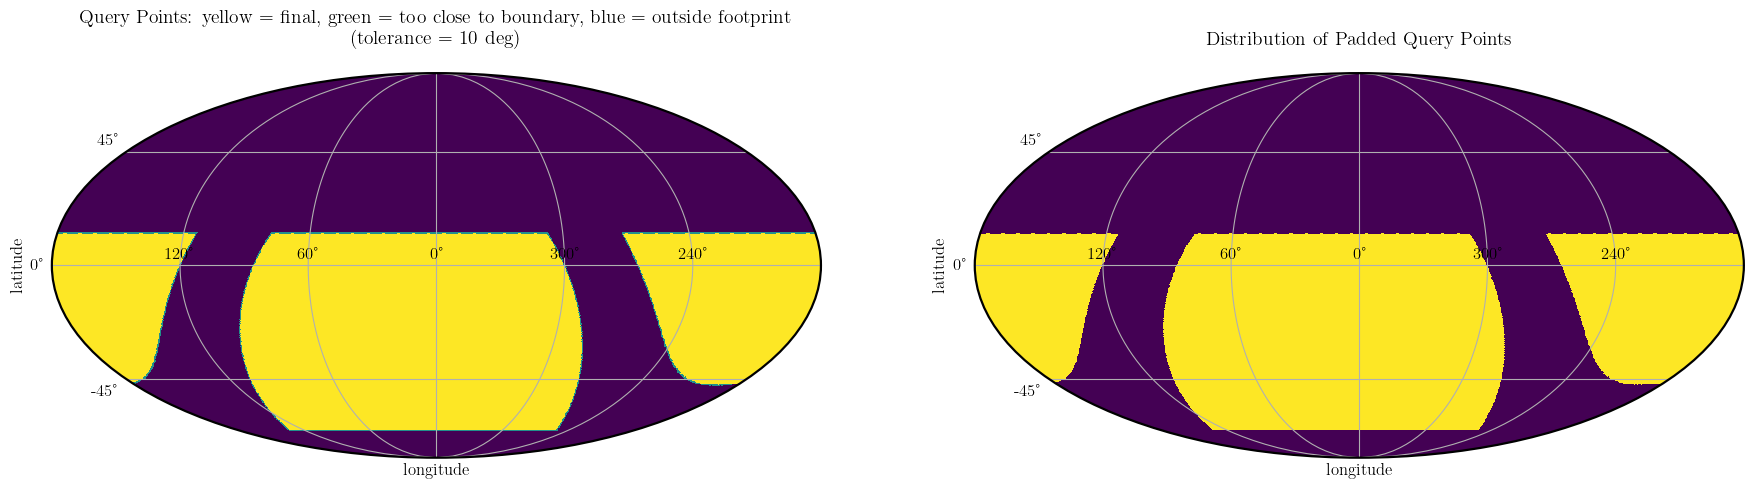

In [61]:
fig = plt.figure(figsize=(18, 7))
ax1, ax2 = plt.subplot(1, 2, 1), plt.subplot(1, 2, 2)

plt.axes(ax1)
projview(
    query_mask,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=False,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"Query Points: yellow = final, green = too close to boundary, blue = outside footprint \n(tolerance = {10} deg)\n",
    norm="linear", 
    flip="astro",
    min = 0,
    max = 2,
    hold=True,
    sub=121
)

hpx_querymap = hf_2DA.cat2hpx(np.rad2deg(query_pos)[:, 1], np.rad2deg(query_pos)[:, 0], nside=NSIDE, radec=False)
plt.axes(ax2)
projview(
    hpx_querymap,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=False,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title="Distribution of Padded Query Points\n",
    norm="linear", 
    flip="astro",
    hold=True,
    sub=122
)

plt.show()
plt.close()

#### Finally, let's compute and plot the nearest-neighbour tracer-field excess cross-correlation as a function of angular scale

In [62]:
# Let's create a combined list of the independent realisations of the randoms and the mock BBHs. This is just so we can get the results using a single call to the function, but you can compute the results separately if you want.

combined_pos_masked_ds_arr = np.concatenate([randoms_pos_masked_ds_arr, bbh_pos_masked_ds_arr], axis=0)

In [63]:
#Computing the nearest-neighbour distributions

bbhxgalaxy_kNN_results_DataVector = kNN_2D_Ang.TracerFieldCross2DA_DataVector(k_List, sel_bins, query_pos, combined_pos_masked_ds_arr, delta_gal_masked, query_mask, delta_threshold, ReturnSmoothedDict=False, Verbose=True)

Checking inputs ...
	done.

initiating step 1 (smoothing the continuous field at the given angular distance scales)...
	done; time taken for step 1: 1.69e+01 s.

initiating step 2 (looping the tracer-field cross-correlation computations over the multiple tracer realisations)...


--------------  Realisation 1/20  --------------


building the BallTree for the discrete tracer set ...
	done; time taken: 2.07e-03 s.

computing the tracer NN distances ...
	done; time taken: 3.99e+00 s.

computing the tracer auto-CDFs P_{>=k} ...
	done; time taken: 2.69e-01 s.

computing the tracer-field cross-correlation ...

	Computing P_(>dt) and P_(>=k, >dt) for k = 1 ...
	Computing P_(>dt) and P_(>=k, >dt) for k = 2 ...
	Computing P_(>dt) and P_(>=k, >dt) for k = 4 ...

	done; time taken: 2.33e-01 s.

time taken for realisation 1: 4.49e+00 s.


--------------  Realisation 2/20  --------------


building the BallTree for the discrete tracer set ...
	done; time taken: 2.05e-03 s.

computing the tracer NN

In [64]:
#Let's extract the auto and cross components of the nearest-neighbour measurements, and compute the excess cross-correlation

autoCDFs = bbhxgalaxy_kNN_results_DataVector[0]
pdt = bbhxgalaxy_kNN_results_DataVector[1]
jointCDFs = bbhxgalaxy_kNN_results_DataVector[2]
psi = hf.kNN_excess_cross_corr(autoCDFs, pdt, jointCDFs)

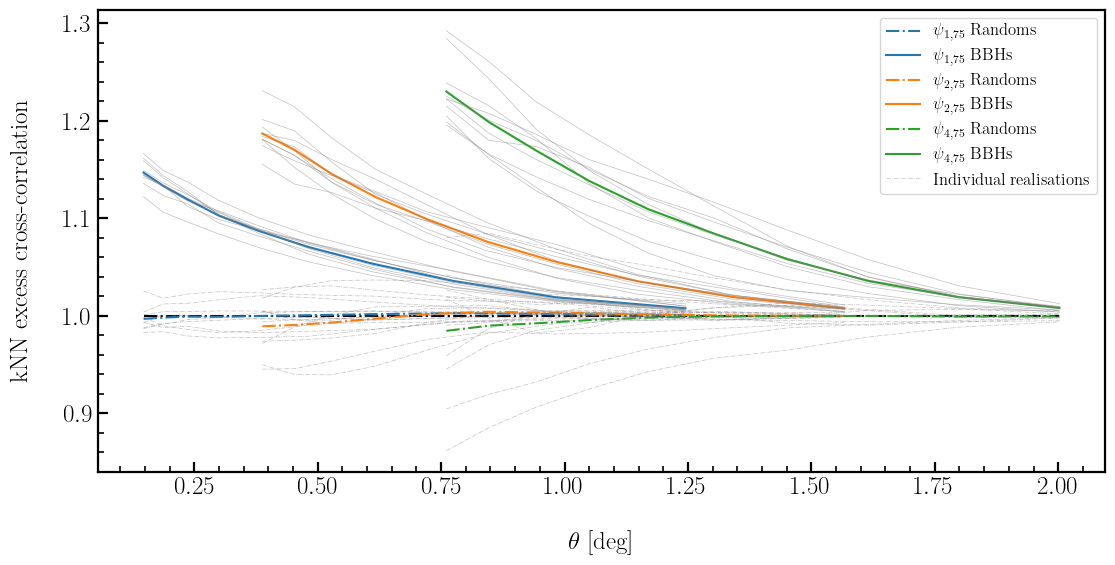

In [65]:
plt.figure(figsize=(13, 6))

x_plots = np.linspace(sel_bins[0][0], sel_bins[-1][-1], 100)
plt.plot(np.rad2deg(x_plots), np.ones_like(x_plots), 'k-.', label=None)

for i, k in enumerate(k_List):
    
    plt.plot(np.rad2deg(sel_bins[i]), np.mean(psi[i][:n_reals], axis=0), c=DefaultColorCycle[i], ls='-.', label='$\\psi_{{{:.0f}, {:.0f}}}$ Randoms'.format(k, delta_threshold))
    for realisation in range(1, n_reals):
        plt.plot(np.rad2deg(sel_bins[i]), psi[i][:n_reals][realisation], c='grey', ls='-.', lw=0.5, alpha=0.5, label=None)

    plt.plot(np.rad2deg(sel_bins[i]), np.mean(psi[i][n_reals:], axis=0), c=DefaultColorCycle[i], label='$\\psi_{{{:.0f}, {:.0f}}}$ BBHs'.format(k, delta_threshold))
    for realisation in range(n_reals):
        plt.plot(np.rad2deg(sel_bins[i]), psi[i][n_reals:][realisation], c='grey', lw=0.5, alpha=0.5, label=None)

plt.plot(np.rad2deg(sel_bins[i]), psi[i][:n_reals][0], c='grey', ls='-.', lw=0.5, alpha=0.5, label='Individual realisations')
        
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('kNN excess cross-correlation\n')
plt.legend(fontsize=12)
plt.show()
plt.close()

#### The results are more noisy than without the mask, but this is not unexpected. What is important is that there is no bias in the measurements (the randoms still average out to an excess cross-correlation of 1), and there is still a very clear clustering signal!

#### <a name="think_ch_1" id="think_ch_1"></a> Thinking challenge

Why do we need to pad the query points? If you are unsure, you can refer to [Gupta & Banerjee (2024)](https://academic.oup.com/mnras/article/531/4/4619/7690170) for a discussion.

**Bonus challenge:** try computing the nearest-neighbour distributions without padding the query points. What is the result? Hint: look at the measurments for the randoms. What do you expect, and what do you see?

#### <a name="comp_ch_1" id="comp_ch_1"></a> Computational challenge

Try varying the tolerance value for the padding. How do the results change? Can you find the optimal value of the padding that leads to the least amount of bias in the results?

In [66]:
# Type your solution below